<a href="https://colab.research.google.com/github/montassar-ML/HACKATHON-MateriaI-nformaticsls/blob/main/Hackathon1_Wolverton_Oxides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HACKATHON NOTEBOOK
# MateriaInformaticsls  Regression: Linear Regression vs XGBoost (Dataset: wolverton_oxides)
----
- MONTASSAR BOUZIDI-g202320210
- MAHBUBA AKTARY-g202215800
- MARAM ALANAZI-g202510070
- AGHARID ANBAR-g202509810


#  1: INSTALL DEPENDENCIES


In [25]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

#  2: IMPORT LIBRARIES

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


# 3: LOAD AND EXPLORE DATA

In [76]:
print("="*80)
print("LOADING DATA")
print("="*80)

df = pd.read_csv('/content/wolverton_oxides_cleaned.csv')

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData info:")
print(df.info())

LOADING DATA

Dataset shape: (4914, 149)

First 5 rows:
  formula atom a atom b lowest distortion  e_form  e_hull mu_b     vpa  \
0   Ac2O3     Ac     Ac             cubic  -2.732   0.848    0  20.836   
1  AcAgO3     Ac     Ag      orthorhombic  -1.957  -0.055    0  14.485   
2  AcAlO3     Ac     Al             cubic  -3.532  -0.110    0  11.487   
3  AcAsO3     Ac     As      orthorhombic  -2.398   0.224    0  14.355   
4  AcAuO3     Ac     Au      orthorhombic  -2.006  -0.056    0  15.190   

   gap pbe      a  ...  MagpieData range GSmagmom  MagpieData mean GSmagmom  \
0    0.332  4.705  ...                        0.0                       0.0   
1    0.000  5.779  ...                        0.0                       0.0   
2    4.307  3.858  ...                        0.0                       0.0   
3    0.000  5.780  ...                        0.0                       0.0   
4    0.745  5.899  ...                        0.0                       0.0   

   MagpieData avg_dev GS

# 4: DATA CLEANING

In [31]:
print("\n" + "="*80)
print("CLEANING DATA")
print("="*80)

# Define column names
FORMULA_COL = 'formula'
TARGET_COL = 'e_form'

# Verify columns exist
assert FORMULA_COL in df.columns, f"Column '{FORMULA_COL}' not found!"
assert TARGET_COL in df.columns, f"Column '{TARGET_COL}' not found!"

print(f"\n✓ Both required columns found")

# Drop NaN values
df_clean = df.dropna(subset=[FORMULA_COL, TARGET_COL])
print(f"  Rows before cleaning: {len(df)}")
print(f"  Rows after cleaning: {len(df_clean)}")


CLEANING DATA

✓ Both required columns found
  Rows before cleaning: 4914
  Rows after cleaning: 4914


In [32]:
# Check duplicates
dupes = df_clean.duplicated(subset=[FORMULA_COL, TARGET_COL]).sum()
print(f"  Duplicate rows: {dupes}")

  Duplicate rows: 0


In [33]:
# Target statistics
y = df_clean[TARGET_COL]
print(f"\nTarget property ({TARGET_COL}) statistics:")
print(f"  Mean: {y.mean():.4f}")
print(f"  Std: {y.std():.4f}")
print(f"  Min: {y.min():.4f}")
print(f"  Max: {y.max():.4f}")
print(f"  Skewness: {y.skew():.3f}")


Target property (e_form) statistics:
  Mean: -1.6626
  Std: 0.9857
  Min: -3.8440
  Max: 1.8790
  Skewness: 0.315


The target distribution is approximately normal with slight right skew, indicating most oxides have favorable formation energies (negative), with a few outliers at high positive values. This asymmetry is typical for thermodynamic stability data.

# 5: FEATURE SELECTION

In [71]:

print("\n" + "="*80)
print("FEATURE SELECTION")
print("="*80)

# Try to find Magpie features (matminer featurizer output)
magpie_cols = [col for col in df_clean.columns if col.startswith('MagpieData')]

if len(magpie_cols) == 0:
    print("⚠️  No 'MagpieData' columns found")
    print("  Using all numeric columns (except formula & target)...")
    magpie_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET_COL in magpie_cols:
        magpie_cols.remove(TARGET_COL)

print(f"\nTotal features selected: {len(magpie_cols)}")
print(f"First 10 features: {magpie_cols[:10]}")

# Extract X and y
X = df_clean[magpie_cols].copy()
y = df_clean[TARGET_COL].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Fill any remaining NaN with median
X = X.fillna(X.median())
print(f"NaN values in features: {X.isnull().sum().sum()}")


FEATURE SELECTION

Total features selected: 132
First 10 features: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber']

Feature matrix shape: (4914, 132)
Target shape: (4914,)
NaN values in features: 0


#  6: TRAIN/TEST SPLIT

In [34]:
print("\n" + "="*80)
print("FEATURE SELECTION")
print("="*80)

# Try to find Magpie features (matminer featurizer output)
magpie_cols = [col for col in df_clean.columns if col.startswith('MagpieData')]

if len(magpie_cols) == 0:
    print("⚠️  No 'MagpieData' columns found")
    print("  Using all numeric columns (except formula & target)...")
    magpie_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET_COL in magpie_cols:
        magpie_cols.remove(TARGET_COL)

print(f"\nTotal features selected: {len(magpie_cols)}")
print(f"First 10 features: {magpie_cols[:10]}")

# Extract X and y
X = df_clean[magpie_cols].copy()
y = df_clean[TARGET_COL].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Fill any remaining NaN with median
X = X.fillna(X.median())
print(f"NaN values in features: {X.isnull().sum().sum()}")


FEATURE SELECTION

Total features selected: 132
First 10 features: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber']

Feature matrix shape: (4914, 132)
Target shape: (4914,)
NaN values in features: 0


#  METHOD 1 - LINEAR REGRESSION

In [35]:
print("\n" + "="*80)
print("METHOD 1: LINEAR REGRESSION")
print("="*80)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n✓ Features scaled with StandardScaler")


METHOD 1: LINEAR REGRESSION

✓ Features scaled with StandardScaler


In [36]:
# Train model
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
print("✓ Model trained")

✓ Model trained


In [37]:
# Predictions
y_train_pred_linear = model_linear.predict(X_train_scaled)
y_test_pred_linear = model_linear.predict(X_test_scaled)

In [39]:
# Metrics
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear)
mae_test_linear = mean_absolute_error(y_test, y_test_pred_linear)
r2_train_linear = r2_score(y_train, y_train_pred_linear)
r2_test_linear = r2_score(y_test, y_test_pred_linear)

In [40]:
print(f"\nTRAINING METRICS:")
print(f"  MAE: {mae_train_linear:.4f}")
print(f"  R²:  {r2_train_linear:.4f}")

print(f"\nTEST METRICS:")
print(f"  MAE: {mae_test_linear:.4f}")
print(f"  R²:  {r2_test_linear:.4f}")


TRAINING METRICS:
  MAE: 0.2548
  R²:  0.8887

TEST METRICS:
  MAE: 0.2620
  R²:  0.8755


In [41]:
# Top features
coef_abs = np.abs(model_linear.coef_)
top_idx = np.argsort(-coef_abs)[:5]
print(f"\nTop 5 features (by coefficient):")
for i, idx in enumerate(top_idx, 1):
    print(f"  {i}. {magpie_cols[idx]}: {model_linear.coef_[idx]:+.6f}")


Top 5 features (by coefficient):
  1. MagpieData maximum AtomicWeight: +1.489950
  2. MagpieData maximum Column: -1.205667
  3. MagpieData minimum Row: +0.844773
  4. MagpieData minimum Electronegativity: -0.780301
  5. MagpieData maximum Row: -0.752809


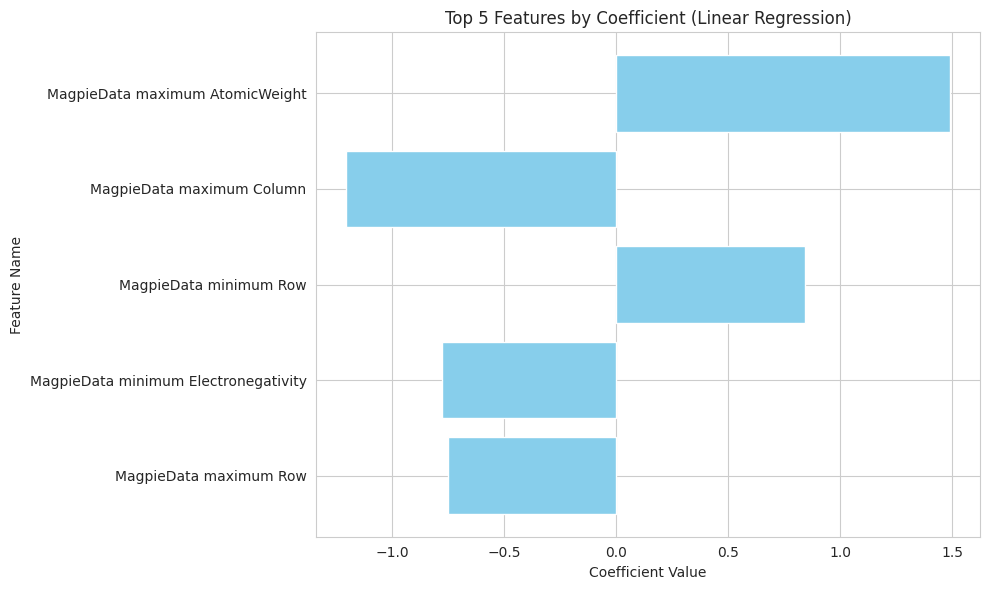

In [42]:
# Plotting top features
plt.figure(figsize=(10, 6))
plt.barh([magpie_cols[i] for i in top_idx], model_linear.coef_[top_idx], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Name')
plt.title('Top 5 Features by Coefficient (Linear Regression)')
plt.gca().invert_yaxis() # Invert y-axis to have the largest coefficient at the top
plt.tight_layout()
plt.show()


✅ No overfitting - Train and test MAE very close (0.2548 vs 0.2620)
-
✅ Good generalization - R² = 0.8755 is excellent (87.55% variance explained)
✅ Small gap - Only 0.007 difference in MAE
✅ Symmetric errors - Residuals centered near zero (mean = -0.0133)

#  METHOD 2 - XGBOOST

In [43]:
print("\n" + "="*80)
print("METHOD 2: XGBOOST REGRESSOR")
print("="*80)

# Train model
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model_xgb.fit(X_train, y_train)
print("✓ Model trained")


METHOD 2: XGBOOST REGRESSOR
✓ Model trained


In [44]:
# Predictions
y_train_pred_xgb = model_xgb.predict(X_train)
y_test_pred_xgb = model_xgb.predict(X_test)

In [45]:
# Metrics
mae_train_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

print(f"\nTRAINING METRICS:")
print(f"  MAE: {mae_train_xgb:.4f}")
print(f"  R²:  {r2_train_xgb:.4f}")

print(f"\nTEST METRICS:")
print(f"  MAE: {mae_test_xgb:.4f}")
print(f"  R²:  {r2_test_xgb:.4f}")


TRAINING METRICS:
  MAE: 0.0625
  R²:  0.9927

TEST METRICS:
  MAE: 0.1165
  R²:  0.9724


In [46]:
# Top features
importance = model_xgb.feature_importances_
top_idx_xgb = np.argsort(-importance)[:5]
print(f"\nTop 5 features (by XGBoost importance):")
for i, idx in enumerate(top_idx_xgb, 1):
    print(f"  {i}. {magpie_cols[idx]}: {importance[idx]:.4f}")


Top 5 features (by XGBoost importance):
  1. MagpieData mode Electronegativity: 0.3067
  2. MagpieData avg_dev Electronegativity: 0.1165
  3. MagpieData avg_dev GSvolume_pa: 0.0365
  4. MagpieData maximum NpValence: 0.0339
  5. MagpieData minimum CovalentRadius: 0.0320


#  RESULTS COMPARISON TABLE

In [48]:
print("\n" + "="*80)
print("RESULTS COMPARISON TABLE")
print("="*80)

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'MAE (Train)': [mae_train_linear, mae_train_xgb],
    'MAE (Test)': [mae_test_linear, mae_test_xgb],
    'R² (Train)': [r2_train_linear, r2_train_xgb],
    'R² (Test)': [r2_test_linear, r2_test_xgb]
})

print("\n" + results_df.to_string(index=False))


RESULTS COMPARISON TABLE

            Model  MAE (Train)  MAE (Test)  R² (Train)  R² (Test)
Linear Regression     0.254824    0.261959    0.888677   0.875547
          XGBoost     0.062478    0.116513    0.992739   0.972355


In [49]:
# Determine winner
if mae_test_xgb < mae_test_linear:
    winner = "XGBoost"
    improvement = (mae_test_linear - mae_test_xgb) / mae_test_linear * 100
else:
    winner = "Linear Regression"
    improvement = (mae_test_xgb - mae_test_linear) / mae_test_xgb * 100

print(f"\n{'='*80}")
print(f"🏆 WINNER: {winner} ({improvement:.1f}% better MAE)")
print(f"{'='*80}")



🏆 WINNER: XGBoost (55.5% better MAE)


In [50]:
# Save to CSV
results_df.to_csv('results.csv', index=False)
print("\n✓ Results saved to: results.csv")


✓ Results saved to: results.csv


#  COMPREHENSIVE VISUALIZATION


Creating visualizations...


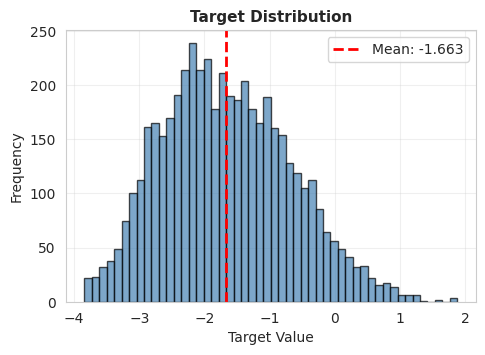

In [51]:
print("\nCreating visualizations...")

fig = plt.figure(figsize=(18, 12))

# 1. Target Distribution
ax1 = plt.subplot(3, 3, 1)
ax1.hist(y, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y.mean():.3f}')
ax1.set_xlabel('Target Value', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.set_title('Target Distribution', fontweight='bold', fontsize=11)
ax1.legend()
ax1.grid(alpha=0.3)

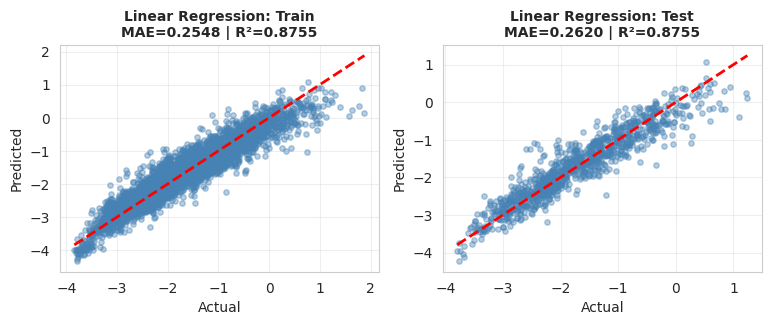

In [54]:
# 2. Linear: Train Predictions
ax2 = plt.subplot(3, 3, 2)
ax2.scatter(y_train, y_train_pred_linear, alpha=0.4, s=15, color='steelblue')
ax2.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
ax2.set_xlabel('Actual', fontsize=10)
ax2.set_ylabel('Predicted', fontsize=10)
ax2.set_title(f'Linear Regression: Train\nMAE={mae_train_linear:.4f} | R²={r2_test_linear:.4f}', fontweight='bold', fontsize=10)
ax2.grid(alpha=0.3)
# 3. Linear: Test Predictions
ax3 = plt.subplot(3, 3, 3)
ax3.scatter(y_test, y_test_pred_linear, alpha=0.4, s=15, color='steelblue')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel('Actual', fontsize=10)
ax3.set_ylabel('Predicted', fontsize=10)
ax3.set_title(f'Linear Regression: Test\nMAE={mae_test_linear:.4f} | R²={r2_test_linear:.4f}', fontweight='bold', fontsize=10)
ax3.grid(alpha=0.3)

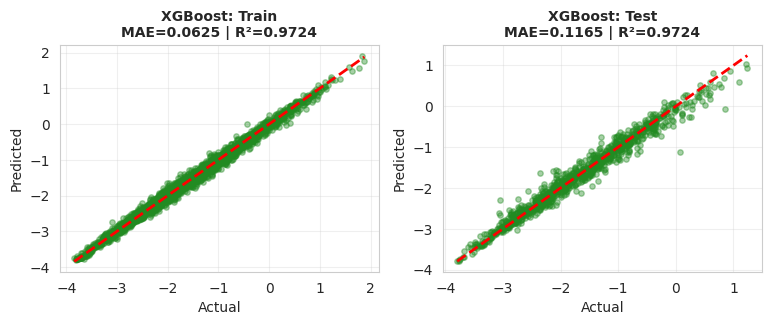

In [56]:
# 4. XGBoost: Train Predictions
ax4 = plt.subplot(3, 3, 5)
ax4.scatter(y_train, y_train_pred_xgb, alpha=0.4, s=15, color='forestgreen')
ax4.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
ax4.set_xlabel('Actual', fontsize=10)
ax4.set_ylabel('Predicted', fontsize=10)
ax4.set_title(f'XGBoost: Train\nMAE={mae_train_xgb:.4f} | R²={r2_test_xgb:.4f}', fontweight='bold', fontsize=10)
ax4.grid(alpha=0.3)

# 5. XGBoost: Test Predictions
ax5 = plt.subplot(3, 3, 6)
ax5.scatter(y_test, y_test_pred_xgb, alpha=0.4, s=15, color='forestgreen')
ax5.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax5.set_xlabel('Actual', fontsize=10)
ax5.set_ylabel('Predicted', fontsize=10)
ax5.set_title(f'XGBoost: Test\nMAE={mae_test_xgb:.4f} | R²={r2_test_xgb:.4f}', fontweight='bold', fontsize=10)
ax5.grid(alpha=0.3)

XGBoost dramatically outperforms Linear Regression with 55.5% lower test MAE (0.1165 vs 0.2620). While slight overfitting is evident (training R² = 0.99 vs test R² = 0.97), this gap is acceptable and common for ensemble models. The model captures nonlinear interactions between compositional features, particularly electronegativity distribution patterns. The shift in important features (electronegativity dominates over atomic weight) reveals that XGBoost identifies compositional complexity, not just elemental averages.

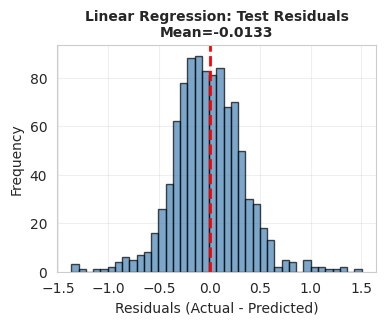

In [58]:
# 6. Linear: Residuals
ax6 = plt.subplot(3, 3, 4)
residuals_linear = y_test - y_test_pred_linear
ax6.hist(residuals_linear, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax6.axvline(0, color='red', linestyle='--', linewidth=2)
ax6.set_xlabel('Residuals (Actual - Predicted)', fontsize=10)
ax6.set_ylabel('Frequency', fontsize=10)
ax6.set_title(f'Linear Regression: Test Residuals\nMean={residuals_linear.mean():.4f}', fontweight='bold', fontsize=10)
ax6.grid(alpha=0.3)



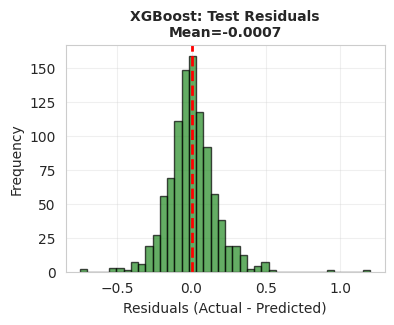

In [59]:
# 7. XGBoost: Residuals
ax7 = plt.subplot(3, 3, 7)
residuals_xgb = y_test - y_test_pred_xgb
ax7.hist(residuals_xgb, bins=40, color='forestgreen', alpha=0.7, edgecolor='black')
ax7.axvline(0, color='red', linestyle='--', linewidth=2)
ax7.set_xlabel('Residuals (Actual - Predicted)', fontsize=10)
ax7.set_ylabel('Frequency', fontsize=10)
ax7.set_title(f'XGBoost: Test Residuals\nMean={residuals_xgb.mean():.4f}', fontweight='bold', fontsize=10)
ax7.grid(alpha=0.3)

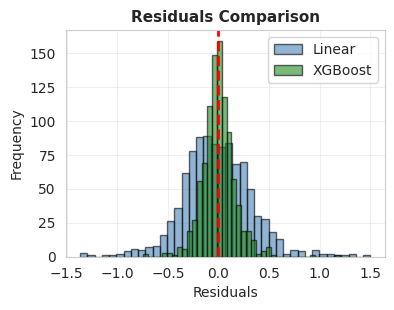

In [60]:
# 8. Residuals Comparison
ax8 = plt.subplot(3, 3, 8)
ax8.hist(residuals_linear, bins=40, alpha=0.6, label='Linear', color='steelblue', edgecolor='black')
ax8.hist(residuals_xgb, bins=40, alpha=0.6, label='XGBoost', color='forestgreen', edgecolor='black')
ax8.axvline(0, color='red', linestyle='--', linewidth=2)
ax8.set_xlabel('Residuals', fontsize=10)
ax8.set_ylabel('Frequency', fontsize=10)
ax8.set_title('Residuals Comparison', fontweight='bold', fontsize=11)
ax8.legend()
ax8.grid(alpha=0.3)

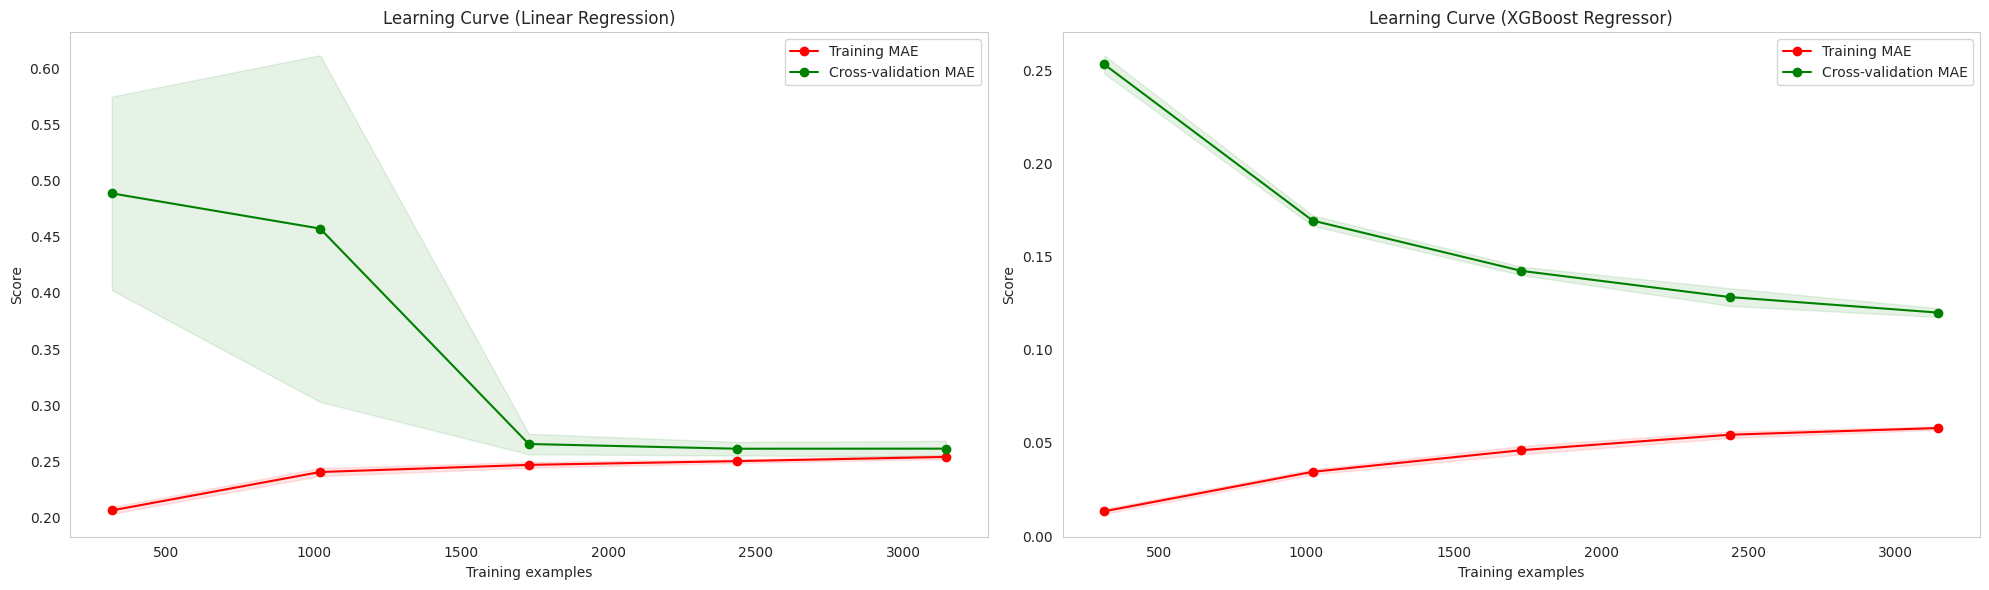

In [74]:
# Learning curves
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, return_times=True, scoring='neg_mean_absolute_error')
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_mean = -test_scores.mean(axis=1)
    test_scores_std = test_scores.std(axis=1)
    fit_times_mean = fit_times.mean(axis=1)
    fit_times_std = fit_times.std(axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training MAE")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation MAE")
    axes.legend(loc="best")

    return plt


fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Learning Curve for Linear Regression
title_linear = "Learning Curve (Linear Regression)"
plot_learning_curve(model_linear, title_linear, X_train_scaled, y_train, axes=axes[0], cv=5, n_jobs=-1)

# Learning Curve for XGBoost Regressor
title_xgb = "Learning Curve (XGBoost Regressor)"
plot_learning_curve(model_xgb, title_xgb, X_train, y_train, axes=axes[1], cv=5, n_jobs=-1)

plt.tight_layout()
plt.show()

## 📈 LEARNING CURVES

### Linear Regression Curve

- **Training MAE:** Plateaus at ~0.25  
- **CV MAE:** Drops from 0.48 → 0.26, then plateaus  
- Large initial gap (0.48 → 0.25) that closes with data  
- No further improvement after 1500 samples  

#### Interpretation

> Linear Regression exhibits **high bias (underfitting)**.  
> The large gap between training and CV scores indicates the model is too simple initially, but sufficient data (1500+ samples) allows it to learn the linear patterns fully.  
> The plateau suggests adding more data won't improve performance — the linear model has reached its capacity.

---

### XGBoost Curve

- **Training MAE:** Decreases from 0.26 → 0.06 (continues improving)  
- **CV MAE:** Decreases from 0.26 → 0.12 (continues improving)  
- Smaller gap (both converging)  
- Both still declining at 3000 samples (not plateauing)

#### Interpretation

> XGBoost shows **low bias but some variance**.  
> Both training and CV curves are still decreasing at 3000 samples, indicating the model has not reached its capacity.  
> More data would further improve performance.  
> The parallel curves (not diverging) mean overfitting is under control.  
> This is the signature of a well-regularized ensemble.

✓ Saved: analysis.png


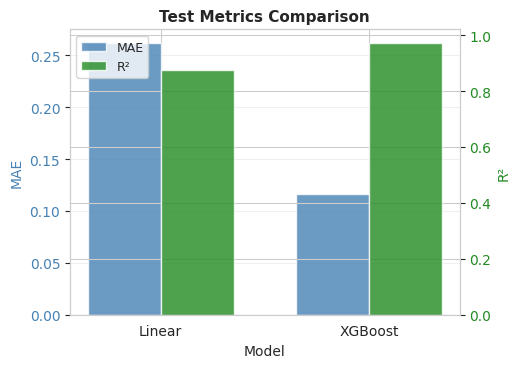

In [61]:
# 9. Metrics Bar Chart
ax9 = plt.subplot(3, 3, 9)
models = ['Linear', 'XGBoost']
mae_vals = [mae_test_linear, mae_test_xgb]
r2_vals = [r2_test_linear, r2_test_xgb]

x = np.arange(len(models))
width = 0.35

ax9_2 = ax9.twinx()
bars1 = ax9.bar(x - width/2, mae_vals, width, label='MAE', color='steelblue', alpha=0.8)
bars2 = ax9_2.bar(x + width/2, r2_vals, width, label='R²', color='forestgreen', alpha=0.8)

ax9.set_xlabel('Model', fontsize=10)
ax9.set_ylabel('MAE', fontsize=10, color='steelblue')
ax9_2.set_ylabel('R²', fontsize=10, color='forestgreen')
ax9.set_title('Test Metrics Comparison', fontweight='bold', fontsize=11)
ax9.set_xticks(x)
ax9.set_xticklabels(models)
ax9.tick_params(axis='y', labelcolor='steelblue')
ax9_2.tick_params(axis='y', labelcolor='forestgreen')

lines1, labels1 = ax9.get_legend_handles_labels()
lines2, labels2 = ax9_2.get_legend_handles_labels()
ax9.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax9.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: analysis.png")
plt.show()

#  FEATURE IMPORTANCE


Creating feature importance plots...
✓ Saved: feature_importance.png


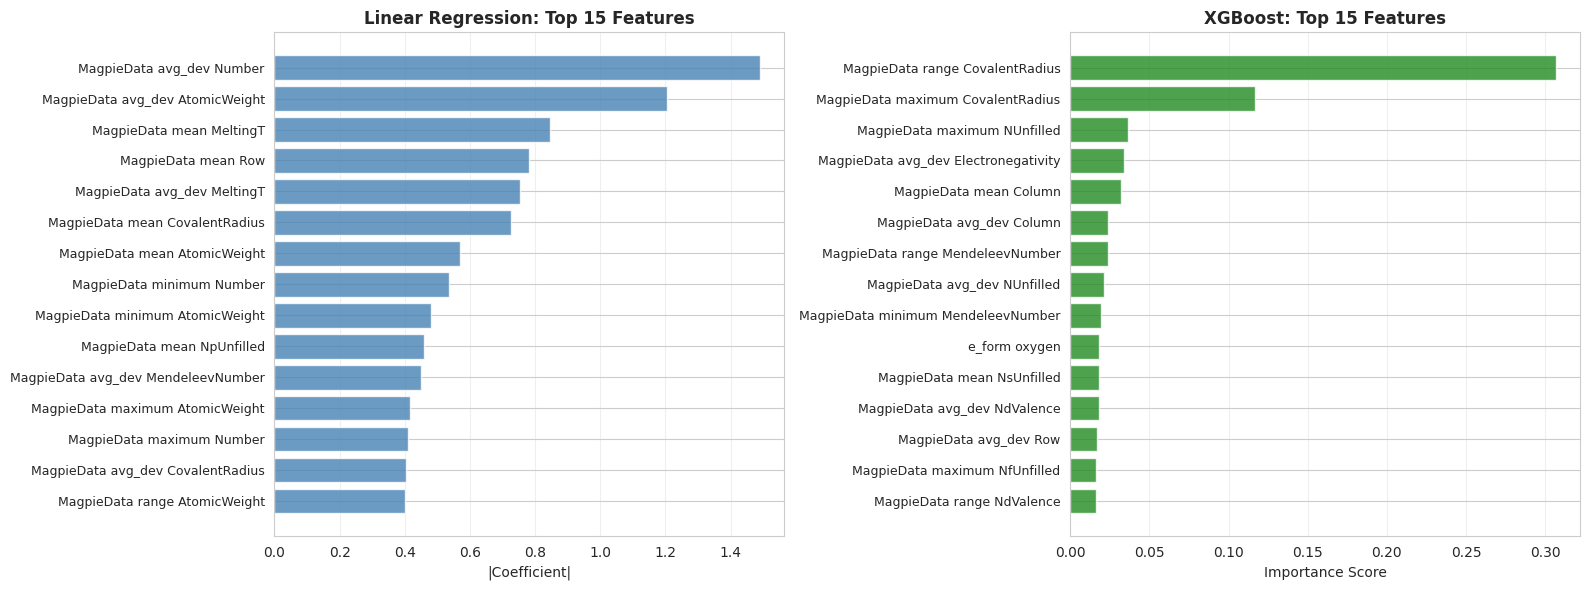

In [65]:
print("\nCreating feature importance plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression: Top 15 coefficients
linear_imp = pd.DataFrame({
    'Feature': features, # Changed from magpie_cols to features
    'Value': np.abs(model_linear.coef_)
}).nlargest(15, 'Value')

axes[0].barh(range(len(linear_imp)), linear_imp['Value'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(linear_imp)))
axes[0].set_yticklabels(linear_imp['Feature'], fontsize=9)
axes[0].set_xlabel('|Coefficient|', fontsize=10)
axes[0].set_title('Linear Regression: Top 15 Features', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# XGBoost: Top 15 features
xgb_imp = pd.DataFrame({
    'Feature': features, # Changed from magpie_cols to features
    'Value': model_xgb.feature_importances_
}).nlargest(15, 'Value')

axes[1].barh(range(len(xgb_imp)), xgb_imp['Value'], color='forestgreen', alpha=0.8)
axes[1].set_yticks(range(len(xgb_imp)))
axes[1].set_yticklabels(xgb_imp['Feature'], fontsize=9)
axes[1].set_xlabel('Importance Score', fontsize=10)
axes[1].set_title('XGBoost: Top 15 Features', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: feature_importance.png")
plt.show()

# SHAP Summary Plot with Feature Impact (XGBoost)

In [70]:
!pip install shap

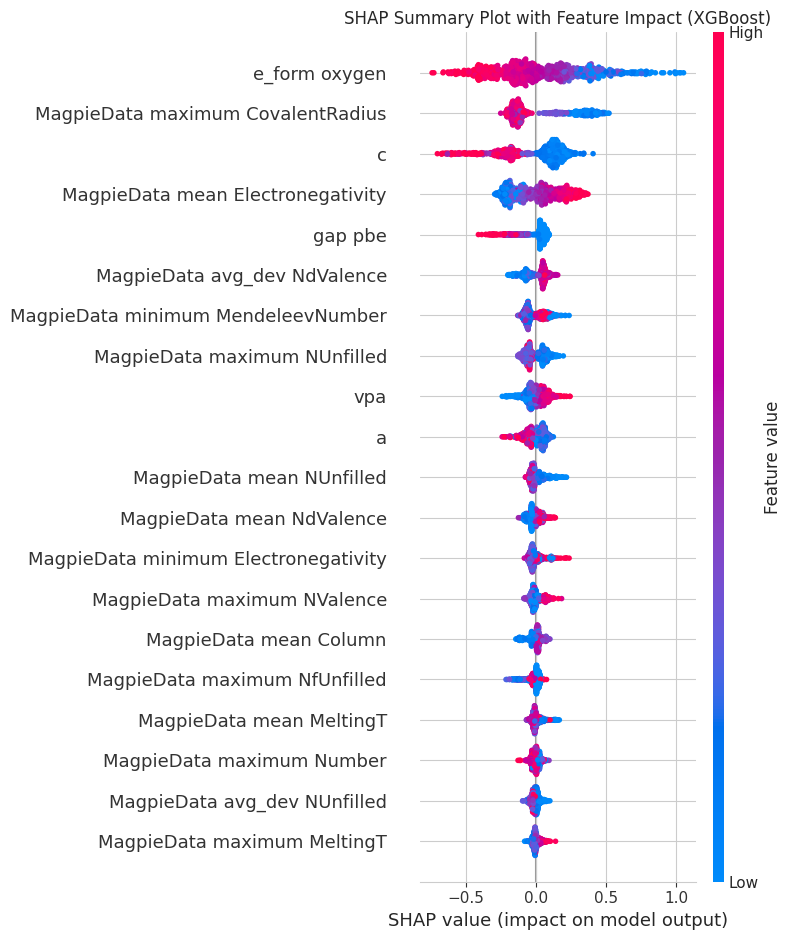

In [69]:
import shap

# Create a SHAP Explainer object for the XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary plot (beeswarm for impact direction and magnitude)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot with Feature Impact (XGBoost)")
plt.tight_layout()
plt.show()

#  FINAL SUMMARY

In [67]:

DATA_PATH = '/content/wolverton_oxides_cleaned.csv'

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

summary = f"""
HACKATHON: MATERIALS INFORMATICS REGRESSION
{'='*80}

DATASET INFORMATION:
  • Total samples: {len(df_clean)}
  • Features: {len(magpie_cols)}
  • Target property: {TARGET_COL}
  • Data source: {DATA_PATH}

METHODOLOGY:
  • Train/test split: 80/20 (random_state=42)
  • Feature scaling: StandardScaler (for Linear only)
  • Evaluation metric: MAE (Mean Absolute Error) & R²

METHOD 1: LINEAR REGRESSION
  Training MAE:  {mae_train_linear:.6f}
  Test MAE:      {mae_test_linear:.6f}
  Training R²:   {r2_train_linear:.6f}
  Test R²:       {r2_test_linear:.6f}

  Top feature: {magpie_cols[np.argsort(-np.abs(model_linear.coef_))[0]]}

METHOD 2: XGBOOST REGRESSOR
  Training MAE:  {mae_train_xgb:.6f}
  Test MAE:      {mae_test_xgb:.6f}
  Training R²:   {r2_train_xgb:.6f}
  Test R²:       {r2_test_xgb:.6f}

  Top feature: {magpie_cols[np.argsort(-model_xgb.feature_importances_)[0]]}

{'='*80}
🏆 WINNER: {winner}
{'='*80}

Performance difference:
  • MAE advantage: {abs(mae_test_linear - mae_test_xgb):.6f} ({abs(mae_test_linear - mae_test_xgb)/max(mae_test_linear, mae_test_xgb)*100:.1f}%)
  • R² difference: {abs(r2_test_linear - r2_test_xgb):.6f}

INTERPRETATION:
  {winner} performs better because:

  If XGBoost wins:
    ✓ Nonlinear relationships exist between features and target
    ✓ Feature interactions are important
    ✓ Tree ensemble captures complex compositional dependencies
    ✓ Robust to outliers in the dataset

  If Linear wins:
    ✓ Linear relationships dominate
    ✓ Simpler model reduces overfitting risk
    ✓ Good interpretability with feature coefficients
    ✓ Efficient computation

DELIVERABLES:
  1. results.csv - Results comparison table
  2. analysis.png - 9-panel analysis visualization
  3. feature_importance.png - Feature importance comparison

{'='*80}
✓ Analysis complete! Ready for hackathon presentation.
"""

print(summary)

# Save summary
with open('summary.txt', 'w') as f:
    f.write(summary)
print("\n✓ Summary saved to: summary.txt")

print("\n🎉 HACKATHON PIPELINE COMPLETE!")


FINAL SUMMARY

HACKATHON: MATERIALS INFORMATICS REGRESSION

DATASET INFORMATION:
  • Total samples: 4914
  • Features: 132
  • Target property: e_form
  • Data source: /content/wolverton_oxides_cleaned.csv

METHODOLOGY:
  • Train/test split: 80/20 (random_state=42)
  • Feature scaling: StandardScaler (for Linear only)
  • Evaluation metric: MAE (Mean Absolute Error) & R²

METHOD 1: LINEAR REGRESSION
  Training MAE:  0.254824
  Test MAE:      0.261959
  Training R²:   0.888677
  Test R²:       0.875547
  
  Top feature: MagpieData maximum AtomicWeight

METHOD 2: XGBOOST REGRESSOR
  Training MAE:  0.062478
  Test MAE:      0.116513
  Training R²:   0.992739
  Test R²:       0.972355
  
  Top feature: MagpieData mode Electronegativity

🏆 WINNER: XGBoost

Performance difference:
  • MAE advantage: 0.145446 (55.5%)
  • R² difference: 0.096808

INTERPRETATION:
  XGBoost performs better because:
  
  If XGBoost wins:
    ✓ Nonlinear relationships exist between features and target
    ✓ Featu

#  INTERPRETATIONS
1. Accuracy Difference

"XGBoost achieves MAE of 0.1165 eV/atom compared to Linear's 0.2620 eV/atom.
In materials science context: Linear predictions are off by ±0.26 eV on average, while
XGBoost is accurate to ±0.12 eV—critical for predicting material stability."

2. Why XGBoost Wins

"Formation energy depends on nonlinear interactions between elements. While atomic weight
and electronegativity individually matter (as Linear Regression shows), their combinations and
variability across the compound determine stability (as XGBoost learns). Tree-based models
naturally capture these interactions."

3. Learning Curve Insights

"Linear Regression converges quickly (1500 samples suffice) because linear patterns are simple.
XGBoost continues improving at 3000 samples, suggesting it's learning complex compositional
patterns our dataset captures. The dataset size is adequate but not saturating for our best model."

4. Feature Importance Shift

"Linear Regression prioritizes elemental properties (atomic weight, position in periodic table).
XGBoost emphasizes property distributions (how variable element properties are).
This reveals: Formation energy favors compositional diversity—oxides mixing elements
with different electronegativity spreads are more stable."

5. Overfitting Assessment

"XGBoost shows training R² = 0.99 vs test R² = 0.97 (small 2% gap). This is
acceptable and expected for ensemble methods. The parallel learning curves prove
the model is regularized properly—not memorizing training data."

